![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [99]:
# Start your code here!
import pandas as pd
import matplotlib.pyplot as plt
men_results = pd.read_csv('men_results.csv', parse_dates=["date"])
women_results = pd.read_csv('women_results.csv', parse_dates=["date"])



In [100]:
fifa_wc_men = men_results[(men_results['date'] > '2002-01-01') & (men_results['tournament'] == 'FIFA World Cup')]
fifa_wc_men

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
25164,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup
25165,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup
25166,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup
25167,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup
25168,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup
...,...,...,...,...,...,...,...
44343,44343,2022-12-10,England,France,1,2,FIFA World Cup
44345,44345,2022-12-13,Argentina,Croatia,3,0,FIFA World Cup
44346,44346,2022-12-14,France,Morocco,2,0,FIFA World Cup
44350,44350,2022-12-17,Croatia,Morocco,2,1,FIFA World Cup


In [101]:
fifa_wc_women = women_results[(women_results['date'] > '2002-01-01') & (women_results["tournament"].isin(["FIFA World Cup"]))]
fifa_wc_men

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
25164,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup
25165,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup
25166,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup
25167,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup
25168,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup
...,...,...,...,...,...,...,...
44343,44343,2022-12-10,England,France,1,2,FIFA World Cup
44345,44345,2022-12-13,Argentina,Croatia,3,0,FIFA World Cup
44346,44346,2022-12-14,France,Morocco,2,0,FIFA World Cup
44350,44350,2022-12-17,Croatia,Morocco,2,1,FIFA World Cup


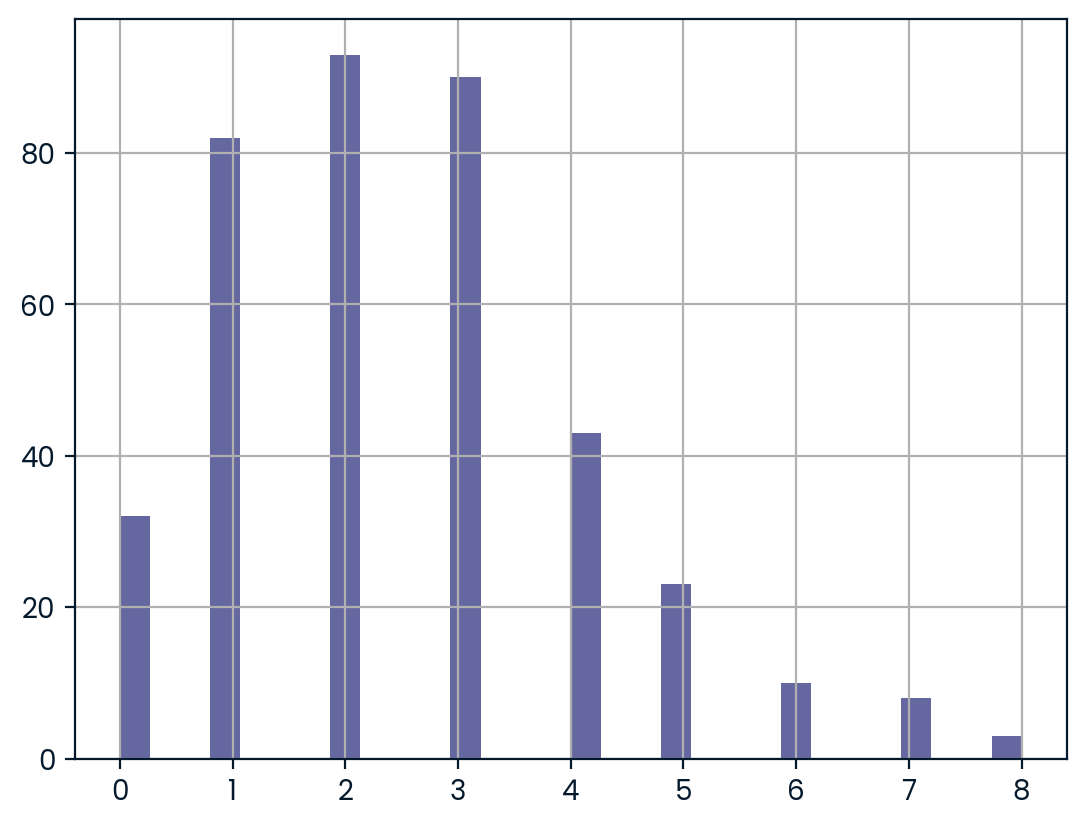

In [102]:
fifa_wc_men['total_score'] = fifa_wc_men['home_score'] + fifa_wc_men['away_score']
fifa_wc_men['total_score'].hist(bins=30)
plt.show()

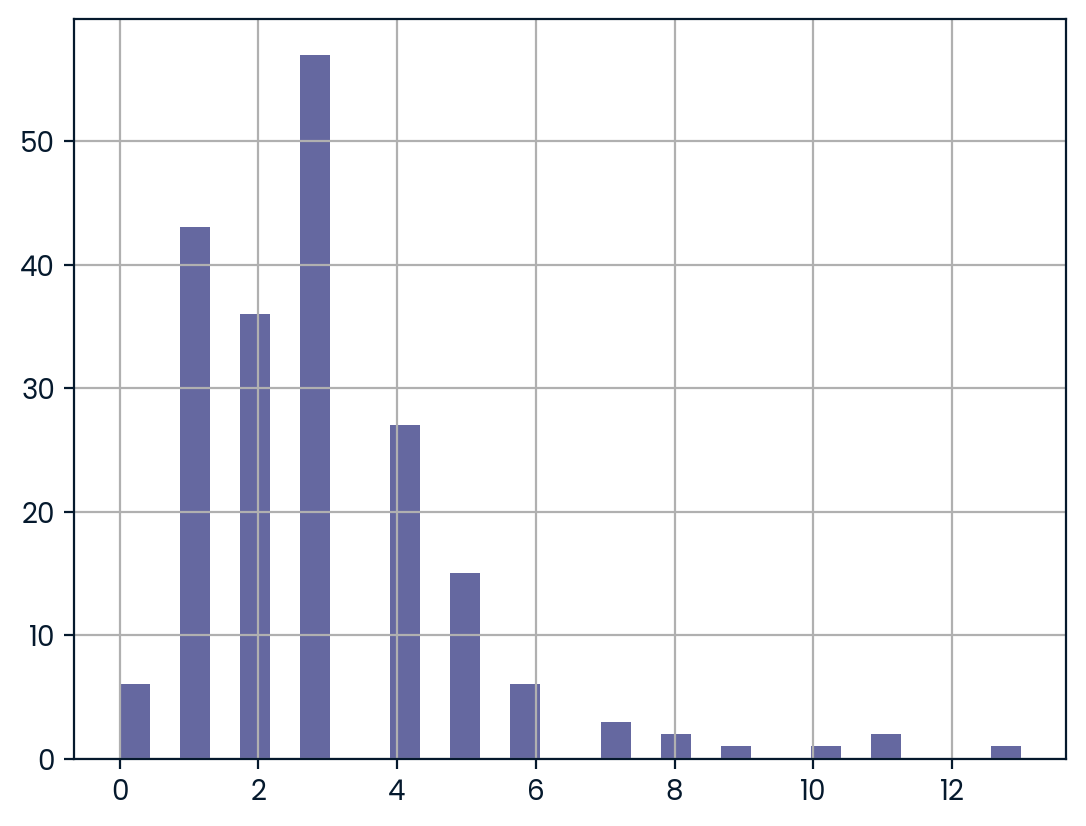

In [103]:
fifa_wc_women['total_score'] = fifa_wc_women['home_score'] + fifa_wc_women['away_score']
fifa_wc_women['total_score'].hist(bins=30)
plt.show()

In [104]:
from scipy.stats import shapiro, mannwhitneyu

stat_m, p_m = shapiro(fifa_wc_men['total_score'])
stat_w, p_w = shapiro(fifa_wc_women['total_score'])
alpha = 0.10

if p_m <= alpha:
    print(f"For Mens p_value of {p_m:.4f}, the data is not normally distributed")
else:
    print("We fail to reject the null hypothesis, therefore it is normally distributted")


For Mens p_value of 0.0000, the data is not normally distributed


In [105]:
if p_w <= alpha:
    print(f"For Mens p_value of {p_w:.4f}, the data is not normally distributed")
else:
    print("We fail to reject the null hypothesis, therefore it is normally distributted")

For Mens p_value of 0.0000, the data is not normally distributed


In [106]:
stats, p_value = mannwhitneyu(x=fifa_wc_women['total_score'],
                            y=fifa_wc_men['total_score'],
                       alternative ='greater')


print(p_value)

result_dict = {"p_val": p_value, "result":"reject"}

0.005106609825443641
